In [ ]:
import os
import re
import time
import html
import requests
import pandas as pd
import xml.etree.ElementTree as ET

# =========================
# CONFIG
# =========================

MY_EMAIL = "merderese0514@gmail.com"   # change if needed
NCBI_TOOL = "aal_dashboard_topic_modeling"

OUTDIR = "data/raw"
OUTFILE = os.path.join(OUTDIR, "papers_multi_source_cleaned.csv")

os.makedirs(OUTDIR, exist_ok=True)

HEADERS = {
    "User-Agent": f"{NCBI_TOOL}/1.0 ({MY_EMAIL})"
}

QUERIES = [
    # dashboard / AAL / older adults
    '"ambient assisted living" dashboard',
    '"ambient assisted living" interface',
    '"older adults" "smart home" dashboard',
    '"older adults" "smart home" interface',
    '"aging in place" dashboard',
    '"aging in place" interface'
    '"caregiver dashboard" "smart home"',
    '"ambient assisted living" interface older adults',
    '"healthy aging" dashboard "smart home"',
    '"older adults" visualization "smart home"',

    # privacy / ethics / trust
    '"smart home privacy" older adults',
    '"ambient assisted living" privacy',
    '"smart home" surveillance ethics elderly',
    '"privacy concerns" "smart home" elderly',
    '"data sharing" "smart home" older adults',
    '"trust" "smart home" older adults',
    '"concerns" "smart home" older adults'
]

# =========================
# HELPERS
# =========================

def safe_get(url, params=None, headers=None, timeout=30, max_retries=5, sleep_base=2):
    """
    GET request with retry/backoff for 429 and server errors.
    """
    hdrs = headers or HEADERS
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, headers=hdrs, timeout=timeout)

            if r.status_code == 200:
                return r

            if r.status_code in (429, 500, 502, 503, 504):
                wait = sleep_base * (2 ** attempt)
                print(f"[retry] {r.status_code} | waiting {wait}s | {url}")
                time.sleep(wait)
                continue

            r.raise_for_status()

        except requests.RequestException as e:
            wait = sleep_base * (2 ** attempt)
            print(f"[error] {e} | waiting {wait}s")
            time.sleep(wait)

    return None


def norm_title(title):
    title = str(title or "").lower().strip()
    title = re.sub(r"\s+", " ", title)
    title = re.sub(r"[^a-z0-9 ]", "", title)
    return title


def clean_text_basic(text):
    text = str(text or "")
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.replace("smart home", "smart_home")
    text = text.replace("older adults", "older_adults")
    text = text.replace("aging in place", "aging_in_place")
    text = text.replace("ambient assisted living", "ambient_assisted_living")
    return text.strip()


def reconstruct_openalex_abstract(inv_idx):
    """
    OpenAlex may return abstract_inverted_index.
    Reconstruct plain abstract text.
    """
    if not inv_idx:
        return ""
    words = {}
    for token, positions in inv_idx.items():
        for pos in positions:
            words[pos] = token
    return " ".join(words[i] for i in sorted(words))


def choose_first_nonempty(values):
    for v in values:
        if isinstance(v, str) and v.strip():
            return v.strip()
    return ""


# =========================
# SOURCE 1: OPENALEX
# =========================

def search_openalex(query, per_page=20, pages=2):
    rows = []
    base = "https://api.openalex.org/works"

    for page in range(1, pages + 1):
        params = {
            "search": query,
            "per-page": per_page,
            "page": page,
            "mailto": MY_EMAIL
        }

        r = safe_get(base, params=params, timeout=30)
        if not r:
            break

        results = r.json().get("results", [])
        print(f"OpenAlex | {query} | page {page} -> {len(results)}")

        for p in results:
            title = clean_text_basic(p.get("title", ""))
            abstract = clean_text_basic(reconstruct_openalex_abstract(p.get("abstract_inverted_index")))
            year = p.get("publication_year", None)

            primary_location = p.get("primary_location") or {}
            source = primary_location.get("source") or {}

            venue = clean_text_basic(source.get("display_name", ""))
            doi = clean_text_basic(p.get("doi", ""))
            url = choose_first_nonempty([
                primary_location.get("landing_page_url", ""),
                primary_location.get("pdf_url", ""),
                p.get("id", ""),
                doi
            ])

            rows.append({
                "query": query,
                "source": "OpenAlex",
                "title": title,
                "abstract": abstract,
                "year": year,
                "venue": venue,
                "doi": doi.lower(),
                "url": url,
                "citationCount": p.get("cited_by_count", None),
            })

        time.sleep(1.5)

    return rows


# =========================
# SOURCE 2: PUBMED
# =========================

def search_pubmed(query, retmax=15):
    rows = []

    esearch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    esearch_params = {
        "db": "pubmed",
        "term": query,
        "retmax": retmax,
        "retmode": "json",
        "tool": NCBI_TOOL,
        "email": MY_EMAIL,
    }

    r = safe_get(esearch_url, params=esearch_params, timeout=30)
    if not r:
        return rows

    ids = r.json().get("esearchresult", {}).get("idlist", [])
    print(f"PubMed | {query} -> {len(ids)}")
    if not ids:
        return rows

    efetch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
    efetch_params = {
        "db": "pubmed",
        "id": ",".join(ids),
        "retmode": "xml",
        "tool": NCBI_TOOL,
        "email": MY_EMAIL,
    }

    r2 = safe_get(efetch_url, params=efetch_params, timeout=60)
    if not r2:
        return rows

    root = ET.fromstring(r2.text)

    for article in root.findall(".//PubmedArticle"):
        title = clean_text_basic(article.findtext(".//ArticleTitle", default=""))

        abstract_parts = []
        for ab in article.findall(".//Abstract/AbstractText"):
            label = ab.attrib.get("Label", "")
            txt = "".join(ab.itertext()).strip()
            txt = clean_text_basic(txt)
            if txt:
                abstract_parts.append(f"{label}: {txt}" if label else txt)

        abstract = " ".join(abstract_parts).strip()

        year = None
        year_text = article.findtext(".//PubDate/Year")
        if year_text and str(year_text).isdigit():
            year = int(year_text)

        venue = clean_text_basic(article.findtext(".//Journal/Title", default=""))

        doi = ""
        for aid in article.findall(".//ArticleId"):
            if aid.attrib.get("IdType") == "doi":
                doi = clean_text_basic(aid.text or "").lower()
                break

        pmid = clean_text_basic(article.findtext(".//PMID", default=""))
        url = f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/" if pmid else ""

        rows.append({
            "query": query,
            "source": "PubMed",
            "title": title,
            "abstract": abstract,
            "year": year,
            "venue": venue,
            "doi": doi,
            "url": url,
            "citationCount": None,
        })

    time.sleep(1.2)
    return rows


# =========================
# SOURCE 3: EUROPE PMC
# =========================

def search_europe_pmc(query, page_size=15, page=1):
    rows = []

    base = "https://www.ebi.ac.uk/europepmc/webservices/rest/search"
    params = {
        "query": query,
        "format": "json",
        "pageSize": page_size,
        "page": page,
        "resultType": "core",
    }

    r = safe_get(base, params=params, timeout=30)
    if not r:
        return rows

    results = r.json().get("resultList", {}).get("result", [])
    print(f"EuropePMC | {query} | page {page} -> {len(results)}")

    for p in results:
        title = clean_text_basic(p.get("title", ""))
        abstract = clean_text_basic(p.get("abstractText", ""))
        year = p.get("pubYear", None)
        year = int(year) if str(year).isdigit() else None
        venue = clean_text_basic(p.get("journalTitle", ""))
        doi = clean_text_basic(p.get("doi", "")).lower()

        pmid = clean_text_basic(p.get("pmid", ""))
        url = f"https://europepmc.org/article/MED/{pmid}" if pmid else ""

        rows.append({
            "query": query,
            "source": "EuropePMC",
            "title": title,
            "abstract": abstract,
            "year": year,
            "venue": venue,
            "doi": doi,
            "url": url,
            "citationCount": None,
        })

    time.sleep(1.2)
    return rows


# =========================
# SOURCE 4: CROSSREF
# =========================

def search_crossref(query, rows_n=15):
    rows = []

    base = "https://api.crossref.org/works"
    params = {
        "query": query,
        "rows": rows_n,
        "select": "DOI,title,abstract,published-print,published-online,container-title,URL,is-referenced-by-count"
    }

    r = safe_get(base, params=params, timeout=30)
    if not r:
        return rows

    items = r.json().get("message", {}).get("items", [])
    print(f"Crossref | {query} -> {len(items)}")

    for p in items:
        title_list = p.get("title", []) or []
        title = clean_text_basic(title_list[0] if title_list else "")
        abstract = clean_text_basic(p.get("abstract", ""))

        year = None
        for field in ["published-print", "published-online"]:
            parts = p.get(field, {}).get("date-parts", [])
            if parts and parts[0] and parts[0][0]:
                year = parts[0][0]
                break

        venue_list = p.get("container-title", []) or []
        venue = clean_text_basic(venue_list[0] if venue_list else "")
        doi = clean_text_basic(p.get("DOI", "")).lower()
        url = clean_text_basic(p.get("URL", ""))

        rows.append({
            "query": query,
            "source": "Crossref",
            "title": title,
            "abstract": abstract,
            "year": year,
            "venue": venue,
            "doi": doi,
            "url": url,
            "citationCount": p.get("is-referenced-by-count", None),
        })

    time.sleep(1.5)
    return rows


# =========================
# RUN COLLECTION
# =========================

all_rows = []

for q in QUERIES:
    print(f"\n===== QUERY: {q} =====")

    all_rows.extend(search_openalex(q, per_page=15, pages=2))
    all_rows.extend(search_pubmed(q, retmax=12))
    all_rows.extend(search_europe_pmc(q, page_size=12, page=1))
    all_rows.extend(search_crossref(q, rows_n=12))

    temp_df = pd.DataFrame(all_rows)
    temp_df.to_csv(os.path.join(OUTDIR, "papers_partial_backup.csv"), index=False)
    print(f"Collected so far: {len(all_rows)}")

    time.sleep(2)

raw_df = pd.DataFrame(all_rows)
print("\nRaw collected shape:", raw_df.shape)


# =========================
# CLEANING + DEDUP
# =========================

df = raw_df.copy()

# standardize core fields
for col in ["title", "abstract", "venue", "doi", "url", "query", "source"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

# keep only rows with title
df = df[df["title"] != ""].copy()

# remove obvious junk / editorial artifacts / peer review records
junk_patterns = [
    r"^review for\s+",
    r"^decision letter\s+",
    r"^response to reviewers",
    r"^review of\s+",
    r"peer review",
    r"editorial",
    r"correction to:",
    r"erratum",
    r"commentary",
]

junk_regex = "|".join(junk_patterns)
df = df[~df["title"].str.lower().str.contains(junk_regex, regex=True, na=False)].copy()

# remove obviously off-scope topics that polluted your earlier run
offscope_patterns = [
    r"covid",
    r"vaccine",
    r"air quality",
    r"smart urban",
    r"food equity",
    r"particle monitoring",
]

offscope_regex = "|".join(offscope_patterns)
df = df[~df["title"].str.lower().str.contains(offscope_regex, regex=True, na=False)].copy()

# build combined document
df["document"] = (df["title"] + ". " + df["abstract"]).apply(clean_text_basic)

# keep only documents with enough text
df = df[df["document"].str.len() > 80].copy()

# strong relevance filter:
# require at least one dashboard/interface term
dashboard_terms = [
    "dashboard", "visualization", "interface", "display", "smart mirror", "user interface"
]

# and at least one domain term
domain_terms = [
    "smart home", "ambient assisted living", "aal", "older adult", "older adults",
    "elderly", "aging", "ageing", "caregiver", "dementia", "home monitoring",
    "independent living", "aging in place", "healthy ageing", "healthy aging"
]

privacy_terms = [
    "privacy", "trust", "ethics", "surveillance", "data sharing", "confidentiality"
]

dashboard_regex = "|".join([re.escape(x) for x in dashboard_terms])
domain_regex = "|".join([re.escape(x) for x in domain_terms])
privacy_regex = "|".join([re.escape(x) for x in privacy_terms])

text_lower = df["document"].str.lower()

# keep papers that satisfy:
# (dashboard/interface AND domain) OR privacy-focused domain papers
keep_mask = (
    (text_lower.str.contains(dashboard_regex, regex=True, na=False) &
     text_lower.str.contains(domain_regex, regex=True, na=False))
    |
    (text_lower.str.contains(domain_regex, regex=True, na=False) &
     text_lower.str.contains(privacy_regex, regex=True, na=False))
)

df = df[keep_mask].copy()

# dedupe by DOI first
df["doi"] = df["doi"].str.lower()
has_doi = df["doi"] != ""

df_doi = df[has_doi].drop_duplicates(subset=["doi"], keep="first").copy()
df_no_doi = df[~has_doi].copy()

# dedupe no-DOI rows by normalized title
df_no_doi["title_norm"] = df_no_doi["title"].apply(norm_title)
df_no_doi = df_no_doi.drop_duplicates(subset=["title_norm"], keep="first").copy()

df_final = pd.concat([df_doi, df_no_doi], ignore_index=True)
df_final = df_final.drop(columns=["title_norm"], errors="ignore")

# remove rows that are still too generic and do not mention older adults / home context
must_have_context = [
    "older adult", "older adults", "elderly", "aging", "ageing",
    "smart home", "ambient assisted living", "aal", "caregiver",
    "dementia", "independent living", "aging in place"
]
context_regex = "|".join([re.escape(x) for x in must_have_context])

df_final = df_final[
    df_final["document"].str.lower().str.contains(context_regex, regex=True, na=False)
].copy()

# sort by year then title
if "year" in df_final.columns:
    df_final["year"] = pd.to_numeric(df_final["year"], errors="coerce")
    df_final = df_final.sort_values(by=["year", "title"], ascending=[False, True])

# save
df_final.to_csv(OUTFILE, index=False)

print("\n===== DONE =====")
print("Saved to:", OUTFILE)
print("Final shape:", df_final.shape)
print("\nSource counts:")
print(df_final["source"].value_counts(dropna=False))
print("\nSample titles:")
print(df_final[["year", "source", "title"]].head(20).to_string(index=False))


===== QUERY: "ambient assisted living" dashboard =====
OpenAlex | "ambient assisted living" dashboard | page 1 -> 15
OpenAlex | "ambient assisted living" dashboard | page 2 -> 15
PubMed | "ambient assisted living" dashboard -> 1
EuropePMC | "ambient assisted living" dashboard | page 1 -> 12
Crossref | "ambient assisted living" dashboard -> 12
Collected so far: 55

===== QUERY: "ambient assisted living" interface =====
OpenAlex | "ambient assisted living" interface | page 1 -> 15
OpenAlex | "ambient assisted living" interface | page 2 -> 15
PubMed | "ambient assisted living" interface -> 12
EuropePMC | "ambient assisted living" interface | page 1 -> 12
Crossref | "ambient assisted living" interface -> 12
Collected so far: 121

===== QUERY: "older adults" "smart home" dashboard =====
OpenAlex | "older adults" "smart home" dashboard | page 1 -> 15
OpenAlex | "older adults" "smart home" dashboard | page 2 -> 15
PubMed | "older adults" "smart home" dashboard -> 0
EuropePMC | "older adults"

In [ ]:
import pandas as pd
import re

df = pd.read_csv("data/raw/papers_multi_source_cleaned.csv")

df["title"] = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")
df["document"] = df["title"].fillna("") + " " + df["abstract"].fillna("")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)      # remove URLs
    text = re.sub(r"\d+", " ", text)          # remove numbers
    text = re.sub(r"[^a-z\s]", " ", text)     # remove punctuation
    text = re.sub(r"\s+", " ", text)          # normalize spaces
    return text.strip()

df["document"] = df["document"].apply(clean_text)

df = df.drop_duplicates(subset=["title"])
df = df[
    ~df["title"].str.lower().str.contains("systematic review|scoping review|narrative review", na=False)
]

print(df.shape)

(257, 10)


In [ ]:
#LDA
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.6,
    min_df=3,
    max_features = 1000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["document"])

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method="batch"
)

lda.fit(X)

feature_names = vectorizer.get_feature_names_out()

print("\nLDA Topics")

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-12:-1]]
    print(f"\nTopic {topic_idx}: {', '.join(top_words)}")


LDA Topics

Topic 0: living, ambient, assisted, assisted living, ambient assisted, aal, user, elderly, systems, technologies, interface

Topic 1: care, technology, older, information, health, people, data, caregivers, support, needs, study

Topic 2: data, based, privacy, iot, monitoring, human, time, learning, using, activity, devices

Topic 3: older, adults, older adults, smart home, technologies, technology, privacy, health, data, care, study

Topic 4: older, adults, older adults, smart home, perceived, use, technology, voice, study, trust, adoption


In [ ]:
topic_dist = lda.transform(X)

df["topic_lda"] = topic_dist.argmax(axis=1)

df[["title","topic_lda"]].head()

,title,topic_lda
0,"""Assistive technology in the home is choice an...",1
1,An AI-Driven Multimodal Smart Home Platform fo...,0
2,Development and User-Centered Evaluation of Sm...,3
3,Development and validation of social compensat...,4
4,Device-Free Indoor Localization with ESP32 Wi-...,2


In [ ]:
for t in sorted(df["topic_lda"].unique()):

    print("\n=======================")
    print("LDA Topic", t)
    print("=======================")

    subset = df[df["topic_lda"] == t]

    for title in subset["title"].head(10):
        print("-", title)



LDA Topic 0
- An AI-Driven Multimodal Smart Home Platform for Continuous Monitoring and Assistance in Post-Stroke Motor Impairment.
- An Interdisciplinary Overview on Ambient Assisted Living Systems for Health Monitoring at Home: Trade-Offs and Challenges.
- BLE-Based Custom Devices for Indoor Positioning in Ambient Assisted Living Systems: Design and Prototyping.
- Advancing affordable IoT solutions in smart homes to enhance independence and autonomy of the elderly
- CUSCO: An Unobtrusive Custom Secure Audio-Visual Recording System for Ambient Assisted Living.
- Developing a Framework for Digital Activities of Daily Living.
- Digital Twin Framework for Personalized Building Management in Ambient Assisted Living
- Healthy and Happy? An Ethical Investigation of Emotion Recognition and Regulation Technologies (ERR) within Ambient Assisted Living (AAL).
- A Decision-Aware Ambient Assisted Living System with IoT Embedded Device for In-Home Monitoring of Older Adults.
- Better Future for H

topic_lda
3    80
0    76
2    55
1    23
4    23
Name: count, dtype: int64


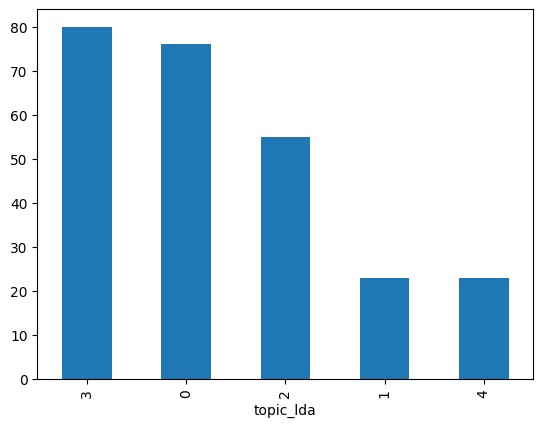

In [ ]:
df["topic_lda"].value_counts().plot(kind="bar")
print(df["topic_lda"].value_counts())